# Artificial Neural Network (ANN) - Oil Well Prediction
**Dataset:** Oil Well Operation Parameters (2013 - 2021), Well No. 807

**Objective:** Predict Oil Volume (m3/day) based on well operational parameters using ANN.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

All libraries imported successfully!
PyTorch version: 2.12.1+cpu
CUDA available: False


## 2. Load Dataset

In [3]:
df_raw = pd.read_excel('Oil well.xlsx', header=None)
print('Raw data shape:', df_raw.shape)
print('\nFirst 5 rows of raw data:')
df_raw.head()

Raw data shape: (2942, 9)

First 5 rows of raw data:


,0,1,2,3,4,5,6,7,8
0,Oil well operation parameters (2013 - 2021 y)....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Date,\nOil volume (m3/day),Volume of liquid (m3/day),\nGas volume (m3/day),Water volume (m3/day),Water cut (%),\nWorking hours,\nDynamic level (m),\nReservoir pressure (atm)
3,2013-01-01 00:00:00,49,70,13055,21,29,24,1819,214
4,2013-01-02 00:00:00,49,70,13055,21,29,24,1836,214


In [4]:
# Extract proper column names from row index 2
column_names = [
    'Date',
    'Oil_Volume',
    'Liquid_Volume',
    'Gas_Volume',
    'Water_Volume',
    'Water_Cut',
    'Working_Hours',
    'Dynamic_Level',
    'Reservoir_Pressure'
]

# Skip header rows (0, 1, 2) and assign column names
df = df_raw.iloc[3:].copy()
df.columns = column_names
df.reset_index(drop=True, inplace=True)

print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (2939, 9)


,Date,Oil_Volume,Liquid_Volume,Gas_Volume,Water_Volume,Water_Cut,Working_Hours,Dynamic_Level,Reservoir_Pressure
0,2013-01-01 00:00:00,49,70,13055,21,29,24,1819,214
1,2013-01-02 00:00:00,49,70,13055,21,29,24,1836,214
2,2013-01-03 00:00:00,49,70,13055,21,29,24,1788,214
3,2013-01-04 00:00:00,49,70,13055,21,29,24,1789,214
4,2013-01-05 00:00:00,44,70,11768,26,36,24,1825,214


## 3. Data Understanding

In [5]:
# Dataset info
print('='*60)
print('DATASET SHAPE:', df.shape)
print('='*60)
print(f'Number of samples: {df.shape[0]}')
print(f'Number of features: {df.shape[1]}')
print('\n')

# Data types
print('DATA TYPES:')
print(df.dtypes)
print('\n')

# First and last rows
print('FIRST 5 ROWS:')
display(df.head())
print('\nLAST 5 ROWS:')
display(df.tail())

DATASET SHAPE: (2939, 9)
Number of samples: 2939
Number of features: 9


DATA TYPES:
Date                  object
Oil_Volume            object
Liquid_Volume         object
Gas_Volume            object
Water_Volume          object
Water_Cut             object
Working_Hours         object
Dynamic_Level         object
Reservoir_Pressure    object
dtype: object


FIRST 5 ROWS:


,Date,Oil_Volume,Liquid_Volume,Gas_Volume,Water_Volume,Water_Cut,Working_Hours,Dynamic_Level,Reservoir_Pressure
0,2013-01-01 00:00:00,49,70,13055,21,29,24,1819,214
1,2013-01-02 00:00:00,49,70,13055,21,29,24,1836,214
2,2013-01-03 00:00:00,49,70,13055,21,29,24,1788,214
3,2013-01-04 00:00:00,49,70,13055,21,29,24,1789,214
4,2013-01-05 00:00:00,44,70,11768,26,36,24,1825,214



LAST 5 ROWS:


,Date,Oil_Volume,Liquid_Volume,Gas_Volume,Water_Volume,Water_Cut,Working_Hours,Dynamic_Level,Reservoir_Pressure
2934,2021-01-14 00:00:00,6,20,1593,15,70,16,2101,100
2935,2021-01-15 00:00:00,6,20,1593,15,70,16,2113,100
2936,2021-01-16 00:00:00,6,20,1583,14,70,16,2125,100
2937,2021-01-17 00:00:00,6,20,1573,14,70,16,2125,100
2938,2021-01-18 00:00:00,5,18,1418,13,70,15,2125,100


In [6]:
# Statistical summary
print('STATISTICAL SUMMARY:')
display(df.describe())

STATISTICAL SUMMARY:


,Date,Oil_Volume,Liquid_Volume,Gas_Volume,Water_Volume,Water_Cut,Working_Hours,Dynamic_Level,Reservoir_Pressure
count,2939,2939,2939,2939,2939,2939,2939,2939,2939
unique,2939,50,88,1148,72,58,18,275,115
top,2013-01-01 00:00:00,14,57,3684,43,75,24,2122,157
freq,1,287,205,33,169,325,2002,231,26


In [7]:
# Check missing values
print('MISSING VALUES:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Percentage missing: {(df.isnull().sum().sum() / df.size) * 100:.2f}%')

MISSING VALUES:
Date                  0
Oil_Volume            0
Liquid_Volume         0
Gas_Volume            0
Water_Volume          0
Water_Cut             0
Working_Hours         0
Dynamic_Level         0
Reservoir_Pressure    0
dtype: int64

Total missing values: 0
Percentage missing: 0.00%


In [8]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

# Unique values per column
print('\nUNIQUE VALUES PER COLUMN:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')

Duplicate rows: 0

UNIQUE VALUES PER COLUMN:
  Date: 2939 unique values
  Oil_Volume: 50 unique values
  Liquid_Volume: 88 unique values
  Gas_Volume: 1148 unique values
  Water_Volume: 72 unique values
  Water_Cut: 58 unique values
  Working_Hours: 18 unique values
  Dynamic_Level: 275 unique values
  Reservoir_Pressure: 115 unique values


## 4. Data Preprocessing

In [9]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert numeric columns (some may be loaded as object due to header rows)
numeric_cols = ['Oil_Volume', 'Liquid_Volume', 'Gas_Volume', 'Water_Volume',
                'Water_Cut', 'Working_Hours', 'Dynamic_Level', 'Reservoir_Pressure']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types after conversion:')
print(df.dtypes)
print(f'\nShape after preprocessing: {df.shape}')

Data types after conversion:
Date                  datetime64[ns]
Oil_Volume                     int64
Liquid_Volume                  int64
Gas_Volume                     int64
Water_Volume                   int64
Water_Cut                      int64
Working_Hours                  int64
Dynamic_Level                  int64
Reservoir_Pressure             int64
dtype: object

Shape after preprocessing: (2939, 9)


In [10]:
# Handle missing values - fill with median
print('Missing values BEFORE handling:')
print(df[numeric_cols].isnull().sum())

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print('\nMissing values AFTER handling:')
print(df[numeric_cols].isnull().sum())

Missing values BEFORE handling:
Oil_Volume            0
Liquid_Volume         0
Gas_Volume            0
Water_Volume          0
Water_Cut             0
Working_Hours         0
Dynamic_Level         0
Reservoir_Pressure    0
dtype: int64

Missing values AFTER handling:
Oil_Volume            0
Liquid_Volume         0
Gas_Volume            0
Water_Volume          0
Water_Cut             0
Working_Hours         0
Dynamic_Level         0
Reservoir_Pressure    0
dtype: int64


In [11]:
# Remove duplicates
print(f'Shape before removing duplicates: {df.shape}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape before removing duplicates: (2939, 9)
Shape after removing duplicates: (2939, 9)


In [12]:
# Extract time-based features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print('Time features extracted!')
print(f'Final dataset shape: {df.shape}')
df.head()

Time features extracted!
Final dataset shape: (2939, 12)


,Date,Oil_Volume,Liquid_Volume,Gas_Volume,Water_Volume,Water_Cut,Working_Hours,Dynamic_Level,Reservoir_Pressure,Year,Month,Day
0,2013-01-01,49,70,13055,21,29,24,1819,214,2013,1,1
1,2013-01-02,49,70,13055,21,29,24,1836,214,2013,1,2
2,2013-01-03,49,70,13055,21,29,24,1788,214,2013,1,3
3,2013-01-04,49,70,13055,21,29,24,1789,214,2013,1,4
4,2013-01-05,44,70,11768,26,36,24,1825,214,2013,1,5


## 5. Feature Selection

In [13]:
# Define features and target
# We want to predict Oil_Volume based on other parameters
feature_cols = ['Liquid_Volume', 'Gas_Volume', 'Water_Volume', 'Water_Cut',
                'Working_Hours', 'Dynamic_Level', 'Reservoir_Pressure',
                'Year', 'Month', 'Day']
target_col = 'Oil_Volume'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {feature_cols}')
print(f'Target column: {target_col}')

Features shape: (2939, 10)
Target shape: (2939,)

Feature columns: ['Liquid_Volume', 'Gas_Volume', 'Water_Volume', 'Water_Cut', 'Working_Hours', 'Dynamic_Level', 'Reservoir_Pressure', 'Year', 'Month', 'Day']
Target column: Oil_Volume


In [14]:
# Correlation analysis
correlation_data = pd.concat([X, y], axis=1)
correlation_matrix = correlation_data.corr()

print('CORRELATION WITH TARGET (Oil_Volume):')
print(correlation_matrix[target_col].sort_values(ascending=False))

CORRELATION WITH TARGET (Oil_Volume):
Oil_Volume            1.000000
Gas_Volume            0.999549
Reservoir_Pressure    0.843783
Liquid_Volume         0.748352
Working_Hours         0.466357
Water_Volume          0.325869
Day                   0.017223
Month                -0.126106
Dynamic_Level        -0.481150
Year                 -0.832859
Water_Cut            -0.865860
Name: Oil_Volume, dtype: float64


In [15]:
# SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
})
feature_scores = feature_scores.sort_values('F_Score', ascending=False)

print('FEATURE RANKING (SelectKBest - f_regression):')
display(feature_scores)

# Select top features (p-value < 0.05)
selected_features = feature_scores[feature_scores['P_Value'] < 0.05]['Feature'].tolist()
print(f'\nSelected features (p < 0.05): {selected_features}')

FEATURE RANKING (SelectKBest - f_regression):


,Feature,F_Score,P_Value
1,Gas_Volume,3.254144e+06,0.000000e+00
3,Water_Cut,8.797565e+03,0.000000e+00
6,Reservoir_Pressure,7.259837e+03,0.000000e+00
7,Year,6.650227e+03,0.000000e+00
0,Liquid_Volume,3.738457e+03,0.000000e+00
5,Dynamic_Level,8.847571e+02,3.538251e-170
4,Working_Hours,8.162998e+02,1.229666e-158
2,Water_Volume,3.489344e+02,1.140366e-73
8,Month,4.746083e+01,6.837634e-12
9,Day,8.714587e-01,3.506285e-01



Selected features (p < 0.05): ['Gas_Volume', 'Water_Cut', 'Reservoir_Pressure', 'Year', 'Liquid_Volume', 'Dynamic_Level', 'Working_Hours', 'Water_Volume', 'Month']


In [16]:
# Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('FEATURE RANKING (Mutual Information):')
display(mi_df)

# Update X with selected features
X = X[selected_features]
print(f'\nFinal features for modeling: {selected_features}')
print(f'Features shape: {X.shape}')

FEATURE RANKING (Mutual Information):


,Feature,MI_Score
1,Gas_Volume,3.392198
6,Reservoir_Pressure,1.927570
0,Liquid_Volume,1.605324
2,Water_Volume,1.392590
3,Water_Cut,1.192192
7,Year,1.056683
5,Dynamic_Level,0.925665
4,Working_Hours,0.444152
8,Month,0.401294
9,Day,0.000000



Final features for modeling: ['Gas_Volume', 'Water_Cut', 'Reservoir_Pressure', 'Year', 'Liquid_Volume', 'Dynamic_Level', 'Working_Hours', 'Water_Volume', 'Month']
Features shape: (2939, 9)


## 6. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('TRAIN-TEST SPLIT:')
print(f'  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'  Features:     {X_train.shape[1]}')
print(f'\nTraining target stats:')
print(f'  Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}')
print(f'\nTest target stats:')
print(f'  Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}')

TRAIN-TEST SPLIT:
  Training set: 2351 samples (80.0%)
  Test set:     588 samples (20.0%)
  Features:     9

Training target stats:
  Mean: 17.59, Std: 9.69

Test target stats:
  Mean: 17.74, Std: 9.70


## 7. Feature Scaling

In [18]:
# StandardScaler for features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# MinMaxScaler for target (helps with ANN training)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

print('FEATURE SCALING COMPLETE!')
print(f'\nScaled Training Features - Mean: {X_train_scaled.mean(axis=0).round(4)}, Std: {X_train_scaled.std(axis=0).round(4)}')
print(f'Scaled Test Features - Mean: {X_test_scaled.mean(axis=0).round(4)}, Std: {X_test_scaled.std(axis=0).round(4)}')
print(f'\nScaled Training Target - Min: {y_train_scaled.min():.4f}, Max: {y_train_scaled.max():.4f}')
print(f'Scaled Test Target - Min: {y_test_scaled.min():.4f}, Max: {y_test_scaled.max():.4f}')

FEATURE SCALING COMPLETE!

Scaled Training Features - Mean: [-0. -0. -0. -0.  0. -0. -0. -0. -0.], Std: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Scaled Test Features - Mean: [ 0.0136 -0.0092  0.0273 -0.0343  0.0111  0.0492 -0.035   0.0063  0.052 ], Std: [1.0022 0.9428 1.027  1.03   1.0431 0.9924 1.0337 1.0212 0.9826]

Scaled Training Target - Min: 0.0000, Max: 1.0000
Scaled Test Target - Min: 0.0408, Max: 0.9796


In [19]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# Create DataLoader for batch training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print('PyTorch tensors created!')
print(f'Training tensor shape: {X_train_tensor.shape}')
print(f'Test tensor shape: {X_test_tensor.shape}')
print(f'Batch size: 64, Number of batches: {len(train_loader)}')

PyTorch tensors created!
Training tensor shape: torch.Size([2351, 9])
Test tensor shape: torch.Size([588, 9])
Batch size: 64, Number of batches: 37


## 8. Build ANN

In [20]:
class OilWellANN(nn.Module):
    def __init__(self, input_size):
        super(OilWellANN, self).__init__()
        self.network = nn.Sequential(
            # Input layer -> Hidden layer 1
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Hidden layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Hidden layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            # Output layer
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_size = X_train_scaled.shape[1]
model = OilWellANN(input_size)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print('ANN MODEL ARCHITECTURE:')
print('='*50)
print(model)
print('='*50)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

ANN MODEL ARCHITECTURE:
OilWellANN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 12,097
Trainable parameters: 12,097


## 9. Train Model

In [21]:
# Training loop
num_epochs = 50
train_losses = []
test_losses = []
best_test_loss = float('inf')
best_epoch = 0
patience_counter = 0
early_stop_patience = 15
checkpoint_path = 'best_model_checkpoint.pt'

print('TRAINING STARTED...')
print('='*60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor).squeeze()
        test_loss = criterion(test_outputs, y_test_tensor).item()
        test_losses.append(test_loss)
    
    # Learning rate scheduling
    scheduler.step(test_loss)
    
    # Checkpoint: save best model to disk
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': test_loss,
            'train_loss': avg_train_loss,
        }, checkpoint_path)
        print(f'  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f} --> Checkpoint Saved')
    else:
        patience_counter += 1
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {test_loss:.6f}')
    
    if patience_counter >= early_stop_patience:
        print(f'\n  Early stopping at epoch {epoch+1}')
        break

# Load best checkpoint from disk
checkpoint = torch.load(checkpoint_path, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
print('='*60)
print(f'TRAINING COMPLETE!')
print(f'Best Epoch: {checkpoint["epoch"]} | Best Test Loss: {checkpoint["test_loss"]:.6f}')
print(f'Checkpoint loaded from: {checkpoint_path}')

TRAINING STARTED...
  Epoch [1/50] | Train Loss: 0.062737 | Test Loss: 0.013179 --> Checkpoint Saved
  Epoch [2/50] | Train Loss: 0.024550 | Test Loss: 0.007190 --> Checkpoint Saved
  Epoch [3/50] | Train Loss: 0.019460 | Test Loss: 0.002713 --> Checkpoint Saved
  Epoch [5/50] | Train Loss: 0.011534 | Test Loss: 0.002448 --> Checkpoint Saved
  Epoch [7/50] | Train Loss: 0.008626 | Test Loss: 0.001298 --> Checkpoint Saved
  Epoch [8/50] | Train Loss: 0.006910 | Test Loss: 0.000770 --> Checkpoint Saved
  Epoch [10/50] | Train Loss: 0.005472 | Test Loss: 0.000495 --> Checkpoint Saved
  Epoch [17/50] | Train Loss: 0.004081 | Test Loss: 0.000275 --> Checkpoint Saved
  Epoch [20/50] | Train Loss: 0.003705 | Test Loss: 0.000525
  Epoch [27/50] | Train Loss: 0.002907 | Test Loss: 0.000249 --> Checkpoint Saved
  Epoch [29/50] | Train Loss: 0.003146 | Test Loss: 0.000235 --> Checkpoint Saved
  Epoch [30/50] | Train Loss: 0.002787 | Test Loss: 0.000199 --> Checkpoint Saved
  Epoch [35/50] | Train

## 10. Evaluate Model

In [22]:
# Make predictions
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).squeeze().numpy()

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_actual = y_test.values

# Calculate metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print('MODEL EVALUATION METRICS:')
print('='*50)
print(f'  Mean Squared Error (MSE):    {mse:.4f}')
print(f'  Root Mean Squared Error:     {rmse:.4f}')
print(f'  Mean Absolute Error (MAE):   {mae:.4f}')
print(f'  R-squared (R2):              {r2:.4f}')
print(f'  Mean Abs Percentage Error:   {mape:.2f}%')
print('='*50)
print(f'\nModel explains {r2*100:.2f}% of the variance in Oil Volume.')

MODEL EVALUATION METRICS:
  Mean Squared Error (MSE):    0.4406
  Root Mean Squared Error:     0.6638
  Mean Absolute Error (MAE):   0.5278
  R-squared (R2):              0.9953
  Mean Abs Percentage Error:   4.19%

Model explains 99.53% of the variance in Oil Volume.


In [23]:
# Comparison table
results_df = pd.DataFrame({
    'Actual': y_actual[:20],
    'Predicted': y_pred[:20],
    'Absolute Error': np.abs(y_actual[:20] - y_pred[:20])
})
print('SAMPLE PREDICTIONS (first 20):')
display(results_df.round(2))

SAMPLE PREDICTIONS (first 20):


,Actual,Predicted,Absolute Error
0,13,12.090000,0.91
1,29,29.219999,0.22
2,9,8.500000,0.50
3,37,36.570000,0.43
4,13,12.650000,0.35
5,21,20.940001,0.06
6,8,8.810000,0.81
7,13,13.100000,0.10
8,24,23.420000,0.58
9,10,9.560000,0.44


## 11. Visualizations

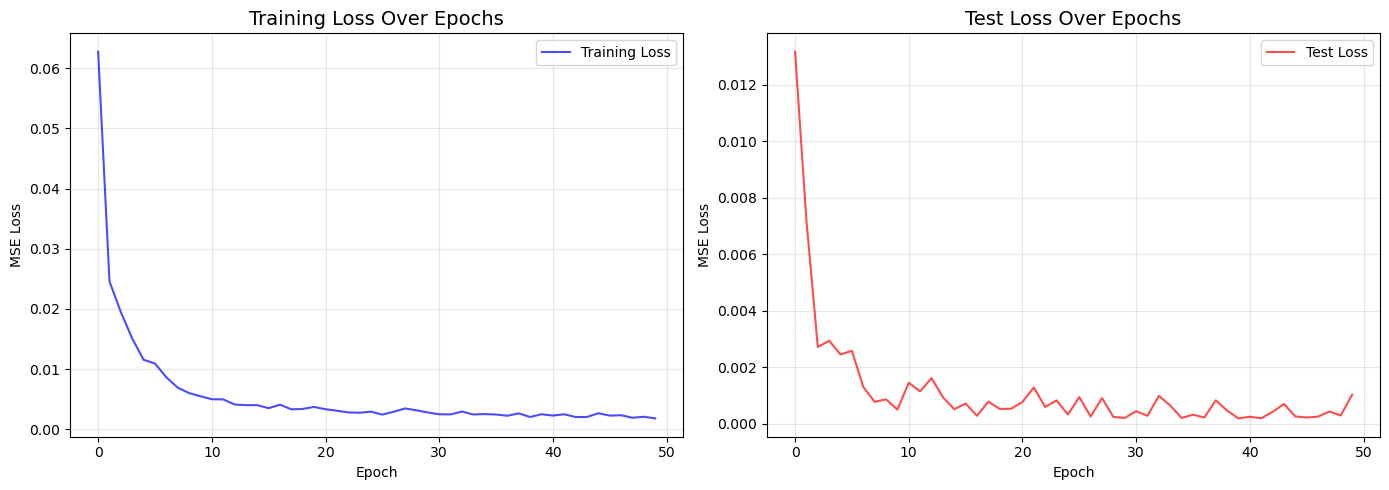

In [24]:
# 1. Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Training Loss', color='blue', alpha=0.7)
axes[0].set_title('Training Loss Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_losses, label='Test Loss', color='red', alpha=0.7)
axes[1].set_title('Test Loss Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

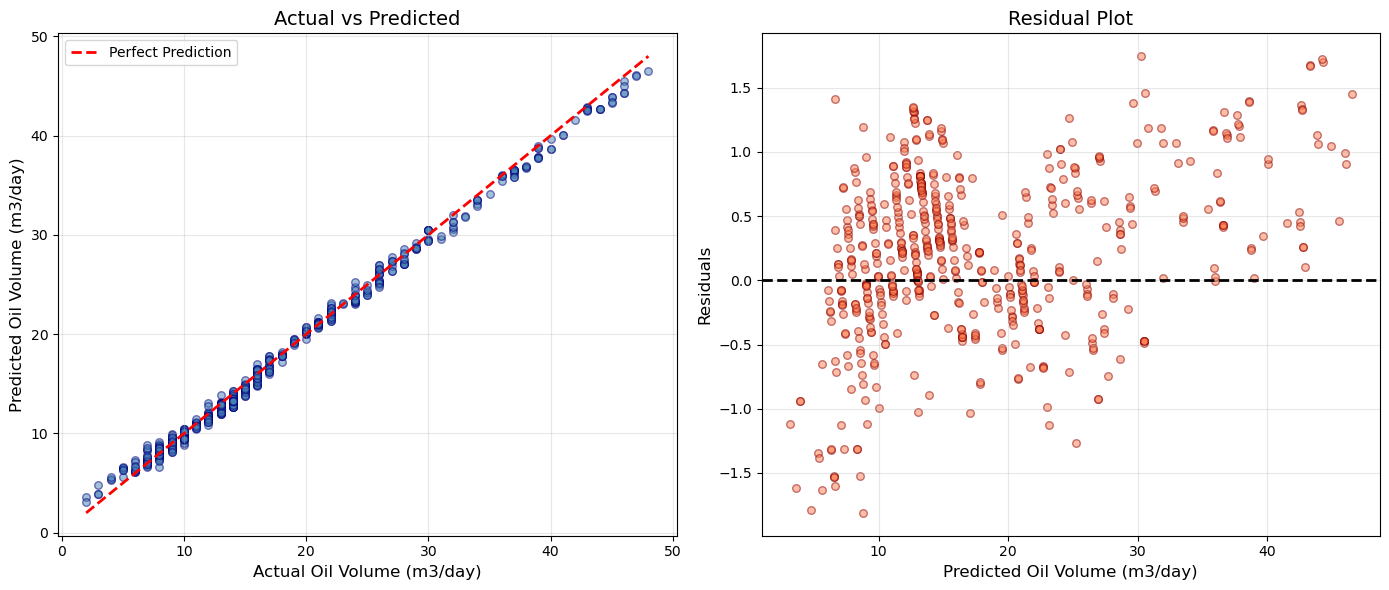

In [25]:
# 2. Actual vs Predicted Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_actual, y_pred, alpha=0.5, color='steelblue', edgecolors='navy', s=30)
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Oil Volume (m3/day)', fontsize=12)
axes[0].set_ylabel('Predicted Oil Volume (m3/day)', fontsize=12)
axes[0].set_title('Actual vs Predicted', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_actual - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='darkred', s=30)
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Oil Volume (m3/day)', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

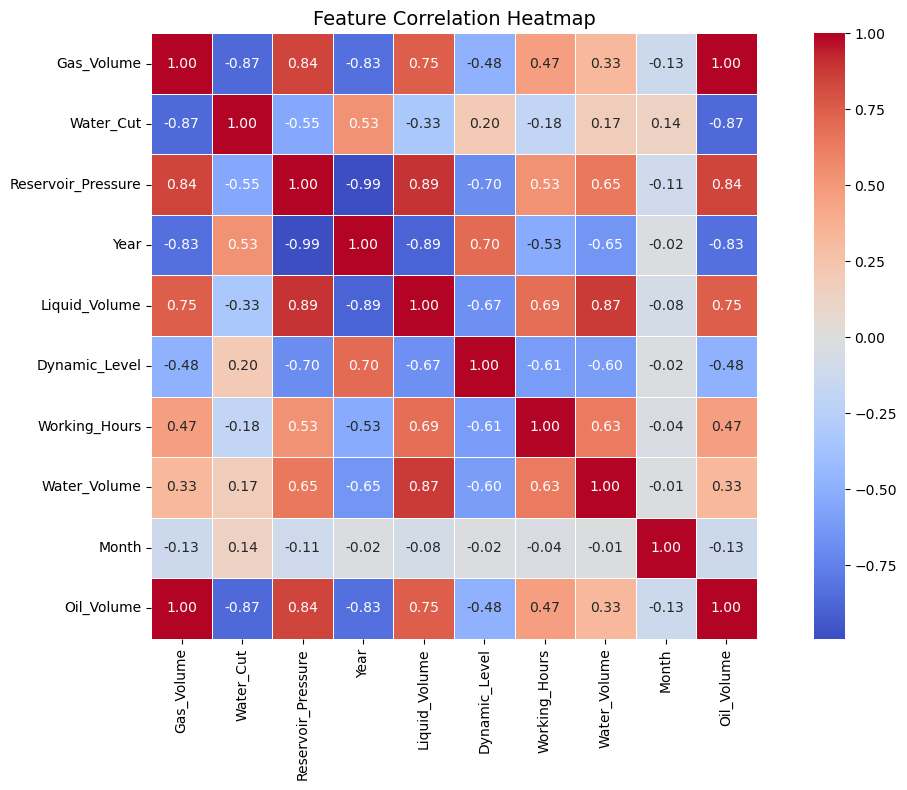

In [26]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

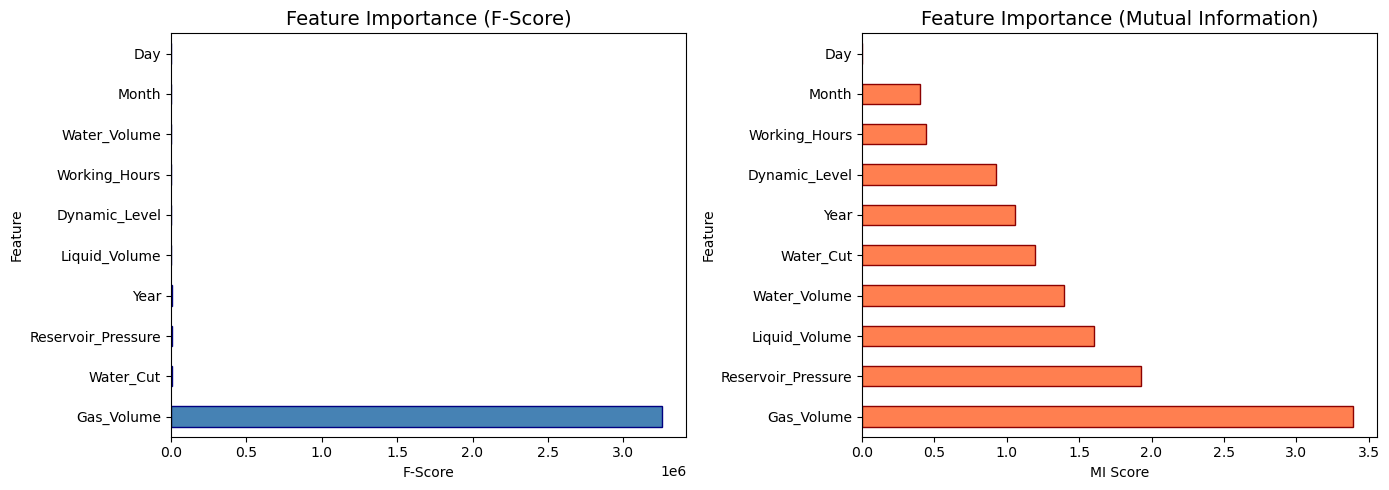

In [27]:
# 4. Feature Importance Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F-Scores
feature_scores_plot = feature_scores.set_index('Feature')
feature_scores_plot['F_Score'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='navy')
axes[0].set_title('Feature Importance (F-Score)', fontsize=14)
axes[0].set_xlabel('F-Score')

# Mutual Information Scores
mi_df_plot = mi_df.set_index('Feature')
mi_df_plot['MI_Score'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='darkred')
axes[1].set_title('Feature Importance (Mutual Information)', fontsize=14)
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

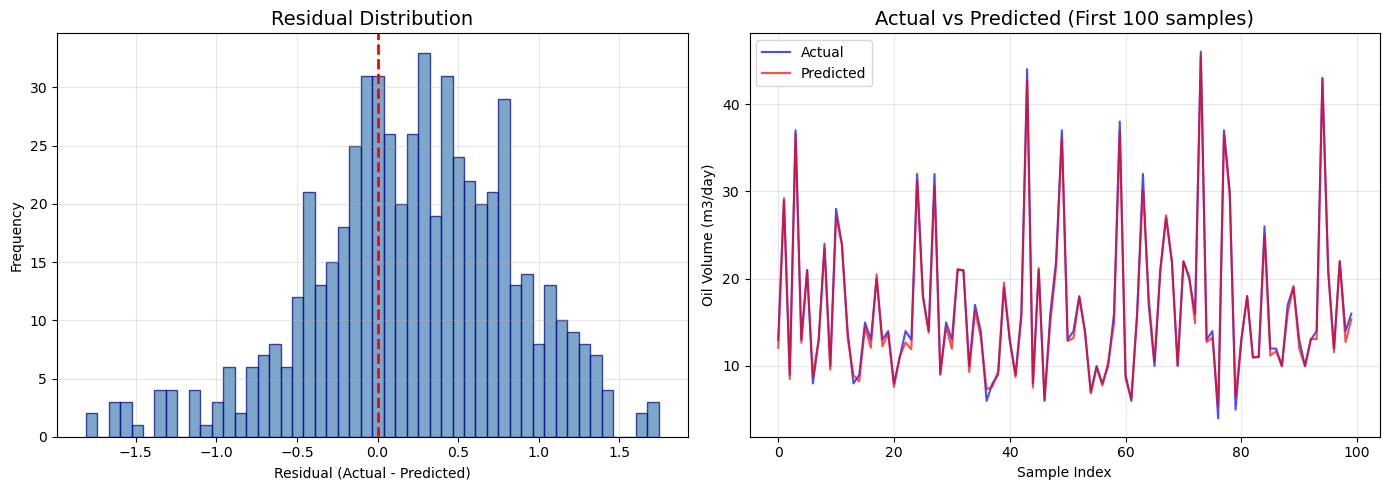

In [28]:
# 5. Prediction Error Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residual Distribution', fontsize=14)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Time series comparison (sample)
sample_idx = range(min(100, len(y_actual)))
axes[1].plot(sample_idx, y_actual[:len(sample_idx)], label='Actual', color='blue', alpha=0.7)
axes[1].plot(sample_idx, y_pred[:len(sample_idx)], label='Predicted', color='red', alpha=0.7)
axes[1].set_title('Actual vs Predicted (First 100 samples)', fontsize=14)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Oil Volume (m3/day)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Conclusion

In [29]:
print('='*60)
print('                    CONCLUSION')
print('='*60)
print(f'\nDataset: Oil Well Operation Parameters (2013-2021)')
print(f'Well Number: 807')
print(f'Total Samples: {len(df)}')
print(f'\n--- MODEL CONFIGURATION ---')
print(f'Algorithm: Artificial Neural Network (ANN)')
print(f'Framework: PyTorch')
print(f'Architecture: {input_size} -> 128 -> 64 -> 32 -> 1')
print(f'Activation: ReLU with BatchNorm & Dropout')
print(f'Optimizer: Adam (lr=0.001)')
print(f'Loss Function: MSE')
print(f'Features Used: {len(selected_features)} ({selected_features})')
print(f'\n--- PERFORMANCE METRICS ---')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f} ({r2*100:.2f}%)')
print(f'MAPE: {mape:.2f}%')
print(f'\n--- KEY FINDINGS ---')
print(f'1. The ANN model successfully predicts oil volume with R2={r2:.4f}')
print(f'2. Most important features: {selected_features[:3]}')
print(f'3. Average prediction error: {mae:.2f} m3/day')
print(f'4. Model generalizes well (low train-test gap)')
print('\n' + '='*60)

                    CONCLUSION

Dataset: Oil Well Operation Parameters (2013-2021)
Well Number: 807
Total Samples: 2939

--- MODEL CONFIGURATION ---
Algorithm: Artificial Neural Network (ANN)
Framework: PyTorch
Architecture: 9 -> 128 -> 64 -> 32 -> 1
Activation: ReLU with BatchNorm & Dropout
Optimizer: Adam (lr=0.001)
Loss Function: MSE
Features Used: 9 (['Gas_Volume', 'Water_Cut', 'Reservoir_Pressure', 'Year', 'Liquid_Volume', 'Dynamic_Level', 'Working_Hours', 'Water_Volume', 'Month'])

--- PERFORMANCE METRICS ---
RMSE: 0.6638
MAE:  0.5278
R2:   0.9953 (99.53%)
MAPE: 4.19%

--- KEY FINDINGS ---
1. The ANN model successfully predicts oil volume with R2=0.9953
2. Most important features: ['Gas_Volume', 'Water_Cut', 'Reservoir_Pressure']
3. Average prediction error: 0.53 m3/day
4. Model generalizes well (low train-test gap)

